# Metadata analysis
Analysis of metadata to check if I can extract something useful for e.g. detecting duplicates

In [ ]:
import os
import json
from typing import Any, Iterator, Optional, Callable
from pathlib import Path
from dotenv import load_dotenv
import seaborn as sns
import pandas as pd

load_dotenv("../.env")
DATA_ROOT = Path(os.environ.get("DATA_ROOT"))
dataset = "Au_01-vol_01"
dir_metadata = DATA_ROOT / f"raw/{dataset}/metadata"
dir_temp = DATA_ROOT.parent / "notebooks/temp"
dir_temp.mkdir(exist_ok=True)

In [2]:
def deep_items(
    d: dict[str, Any], prefix: tuple[str, ...] = ()
) -> Iterator[tuple[str, Any]]:
    """Recursively yield (key.path, value) for all non-dict values
    in a nested dictionary."""
    for k, v in d.items():
        if isinstance(v, dict):
            yield from deep_items(v, prefix + (k,))
        else:
            path = prefix + (k,)
            yield ".".join(path), v


def flatten_dict(d: dict[str, Any]) -> dict[str, Any]:
    """Flatten a nested dictionary. Key hierarchy is preserved by assigning new
    keys as 'a.b.c'."""
    return dict(deep_items(d))


def compare_dicts(
    d1: dict[str, Any],
    d2: dict[str, Any],
    key_filter: Optional[Callable[[str], bool]] = None,
    comparator: Optional[Callable[[str, Any, Any], bool]] = None,
) -> Iterator[tuple[str, list[Any, Any]]]:
    """
    Compare flat dictionaries and yield elements where the comparator returns True.
    If no comparator is specified, the function uses a simple inequality.

    Args:
        d1, d2: Dictionaries to compare (same keys, str keys).
        key_filter: Function(key) -> bool, only compare these keys.
        comparator: Function(key, v1, v2) -> bool, return True if considered different.

    Yields:
        (key, [v1, v2]) for differing elements.
    """

    def calc_diff(v1: Any, v2: Any) -> Any:
        try:
            return v2 - v1
        except TypeError:
            return None

    keys = d1.keys() if key_filter is None else filter(key_filter, d1.keys())
    for key in keys:
        v1, v2 = d1[key], d2[key]
        if comparator is None:
            if v1 != v2:
                yield key, [v1, v2, calc_diff(v1, v2)]
        else:
            if comparator(key, v1, v2):
                yield key, [v1, v2]


def compare_metadata(
    metadata: list[dict[str, Any]], files: list[Path]
) -> list[dict[str, Any]]:
    """Compare metadata and find values that do not match"""

    max_ix = len(files) - 1

    def key_filter(x: str) -> bool:
        return "Stage" in x

    def get_files(ix: int) -> dict[str, Any]:
        return {"Files": [files[ix].name, files[ix + 1].name, "diff"]}

    comparison = [
        dict(compare_dicts(metadata[i], metadata[i + 1], key_filter)) | get_files(i)
        for i in range(max_ix)
    ]

    return comparison


def get_diff_value(d: dict, key: str) -> float:
    """Get difference value from dictionary key. Returns 0 is no key, which
    happens when there's no difference"""
    val = d.get(key)
    return val[2] if val else 0

In [3]:
files = sorted(list(dir_metadata.glob("*-metadata.json")))
metadata_flat = [flatten_dict(json.loads(file.read_text())) for file in files]
metadata_diff = compare_metadata(metadata_flat, files)
with open(dir_temp / f"{dataset}-metadata-stage-diff.json", "w") as file:
    json.dump(metadata_diff, file, indent=4)

In [4]:
data = pd.DataFrame(
    {
        "stage_x": [get_diff_value(i, "EBeam.StageX") for i in metadata_diff],
        "stage_y": [get_diff_value(i, "EBeam.StageY") for i in metadata_diff],
        "files": [i.get("Files")[:2] for i in metadata_diff],
    }
)

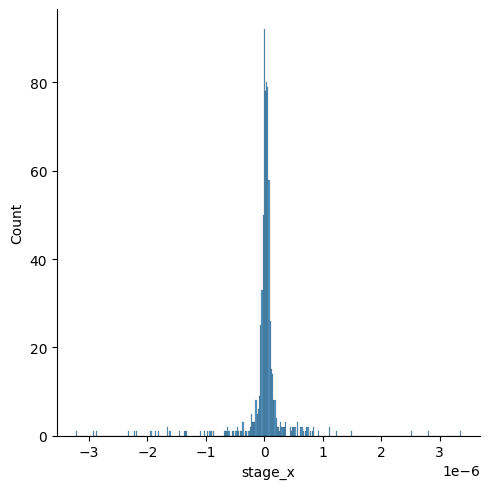

In [5]:
g = sns.displot(data=data, x="stage_x", kind="hist")

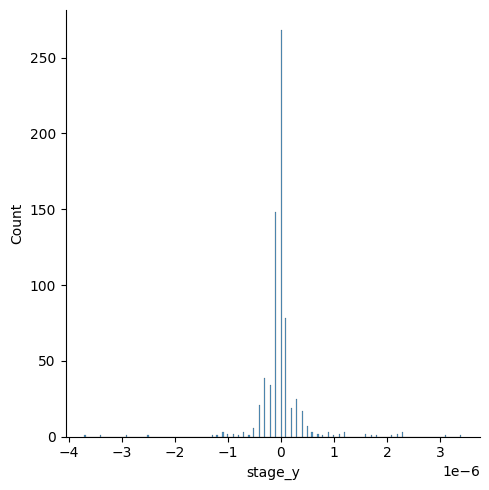

In [6]:
g = sns.displot(data=data, x="stage_y", kind="hist")